<a href="https://colab.research.google.com/github/DimKapoulas/dynamic-futures-hedging-simulation/blob/main/dynamic_futres_hedging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario Analysis and Dynamic Futures Hedging
**Author:** Dimitris Kapoulas  
**Contact:** dimkapoulas@gmail.com | https://www.linkedin.com/in/dimitris-kapoulas/  
**Academic Background:** Graduate, Department of Economics  


This notebook explores the effectiveness of hedging strategies, first through a scenario analysis at maturity, and then by implementing a dynamic hedging approach using simulated asset prices.

**DISCLAIMER: This does not constitute an investment proposition and should not be used as so.**

### 1. Scenario Analysis at Maturity

We'll begin by examining two simple scenarios at the maturity of a futures contract: one where the spot price decreases ($S_T < S_0$) and one where it increases ($S_T > S_0$). This helps illustrate how a hedged position behaves under different market movements and highlights the impact of correlation (or lack thereof).

**Initial Setup:**

*   **Spot Price ($S_0$):** \$50 per unit
*   **Futures Price ($F_0$):** \$50 per unit
*   **Quantity of Asset ($Q$):** 100,000 units
*   **Futures Contract Size ($q$):** 1,000 units
*   **Optimal Hedge Ratio ($h^*$):** 0.4
*   **Investment Duration ($T$)**: 0.5 (half a year)

**Optimal number of Futures Contracts ($N^*$):** We'll hold a short position.

The optimal hedge ratio $h^*$ is calculated as:
$h^* = \rho \left( \frac{\sigma_S}{\sigma_F} \right) = 0.4 \times \left( \frac{0.25}{0.25} \right) = 0.4$

Then, the number of contracts is:
$N^* = -h^* \times \frac{Q}{q} = -0.4 \times \frac{100,000}{1,000} = -40 \text{ contracts}$

**Calculations for Profit and Loss (P&L):**

*   **Spot Market P&L:** $\text{Spot P&L} = Q \times (S_T - S_0)$
*   **Futures Market P&L:** $\text{Futures P&L} = N^* \times q \times (F_T - F_0)$
*   **Total Hedged P&L:** $\text{Total P&L} = \text{Spot P&L} + \text{Futures P&L}$

Through these scenarios, we'll see that hedging reduces downside risk but also limits upside gains. It doesn't eliminate all risk, primarily due to **basis risk**, which is the risk that spot and futures prices don't move in perfect lockstep, meaning $F_T \neq S_T$ at maturity.

So without any further ado, let us proceed by importing some essential libraries and setting up our simulation

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# Half a year (6 moths) on daily steps
T = 0.5
dt = 1/252
N_steps = int(T / dt)
N_simulations = 5000

# Asset price parameteres
S0 = 50
mu_S = 0.05
sigma_S = 0.25

# Futures price parameters
F0 = 50
mu_F = 0.05
sigma_F = 0.25

# Corelation between Spot and Futures
rho_SF = 0.9

# Quantity of position (Q) and futures contract size (q)
Q = 5000
q = 50
transaction_cost  = 0.001



**The Dynamic Hedging Process:**

1.  **Simulate Price Paths**: Generate $S_t$ and $F_t$ paths using GBM.
2.  **Estimate Hedge Ratios**: At each time step, estimate $h^*$ using linear regression on historical price changes.
3.  **Adjust Hedge Positions**: Dynamically update the number of futures contracts based on the estimated $h^*$.
4.  **Calculate P&L**: Track the P&L for both the asset and futures positions.
5.  **Evaluate Effectiveness**: Compare the P&L distributions and risk metrics of the hedged versus unhedged positions to assess the strategy's performance.

We will now set up our time axis and initialize some matrices that will keep the realized stochastic paths later.

In [31]:
# Time array, x-axis
time_grid = np.linspace(0, T, N_steps + 1)


# Initialize the path arrays
S_paths = np.zeros((N_simulations, N_steps + 1))
F_paths = np.zeros((N_simulations, N_steps + 1))

# Set simulation prices to S0 and F0
S_paths[:, 0] = S0
F_paths[:, 0] = F0

### 2. Cholesky Decomposition for Correlated Random Variables

When conducting financial simulations, especially when modeling multiple assets, it's crucial to account for the **correlation** between them. Simply generating independent random numbers for each asset would ignore their interconnectedness, leading to unrealistic simulation results.

The core idea is to transform a set of independent standard normal random variables into a set of correlated standard normal random variables that reflect market reality. Cholesky decomposition provides a robust and efficient way to achieve this.

#### **The Transformation Process:**

**i. Covariance Matrix ($Σ$):**  
We define a covariance matrix that represents the desired correlation structure between the spot price ($S$) and futures price ($F$). Since we start with standard normal variables (variance = 1), the matrix looks like this:
$$\Sigma = \begin{pmatrix} 1 & \rho_{SF} \\ \rho_{SF} & 1 \end{pmatrix}$$

**ii. Cholesky Factor ($L$):**  
The Cholesky decomposition factorizes the symmetric, positive-definite matrix $Σ$ into the product of a lower triangular matrix ($L$) and its conjugate transpose ($L^T$):
$$\Sigma = L L^T$$
This `chol_matrix` ($L$) acts as our linear transformation operator.

**iii. Applying the Correlation:**  
By multiplying a vector of independent random shocks $\mathbf{z}$ by the Cholesky factor $L$, we produce the correlated shocks used in our GBM equations:
$$\mathbf{z}_{correlated} = L \mathbf{z}_{independent}$$

In this simulation, this ensures that the random 'shocks' applied to $S_t$ and $F_t$ maintain the specified $\rho_{SF}$, making the paths consistent with observed market behavior.

In [32]:
# Cholesky decomposition for correlated random variables
cov_matrix = np.array([[1, rho_SF], [rho_SF, 1]])
chol_matrix = np.linalg.cholesky(cov_matrix)


### 3. Dynamic Hedging Strategy

Financial markets are constantly changing, so a static hedge isn't always optimal. Dynamic hedging involves periodically adjusting the hedge position.

**Simulating Asset Prices with Geometric Brownian Motion (GBM):**

and futures ($F_t$) prices. GBM is a common model that captures key characteristics of asset prices:

*   **Spot Price SDE:** $dS_t = \mu_S S_t dt + \sigma_S S_t dW^S_t$
*   **Futures Price SDE:** $dF_t = \mu_F F_t dt + \sigma_F F_t dW^F_t$

Where $dW^S_t$ and $dW^F_t$ are Wiener processes, and their correlation is defined by $dW^S_t dW^F_t = \rho_{SF} dt$.

For numerical simulation, we use the discretized forms:

*   $S_{t+\Delta t} = S_t \times \exp\left(\left(\mu_S - \frac{\sigma_S^2}{2}\right)\Delta t + \sigma_S Z_S \sqrt{\Delta t}\right)$
*   $F_{t+\Delta t} = F_t \times \exp\left(\left(\mu_F - \frac{\sigma_F^2}{2}\right)\Delta t + \sigma_F Z_F \sqrt{\Delta t}\right)$

Here, $Z_S$ and $Z_F$ are correlated standard normal random variables. We'll use the **Cholesky decomposition** that we implemented in the previous step to generate these correlated random variables from independent ones, ensuring our simulations accurately reflect the `rho_SF` correlation.


In [33]:
# Procude the stochastic paths
for i in range(N_simulations):
  for t in range(1, N_steps + 1):
    # Generate standard normal variables
    z = np.random.normal(size=2)
    correlated_z = chol_matrix @ z

    # Simulate asset price
    S_paths[i, t] = S_paths[i, t - 1] * np.exp((mu_S - sigma_S ** 2 / 2) * dt +
                                               sigma_S * correlated_z[0] * np.sqrt(dt))

    # Simulate futures price
    F_paths[i, t] = F_paths[i, t - 1] * np.exp((mu_F - sigma_F ** 2 / 2) * dt +
                                               sigma_F * correlated_z[1] * np.sqrt(dt))


In [34]:

print(S_paths.shape)
print(F_paths.shape)

(5000, 127)
(5000, 127)


### 4. Estimating the Optimal Hedge Ratio ($h^*$) Dynamically

The optimal hedge ratio changes as market conditions evolve. We can estimate it at each time step using linear regression.

*   The variance-minimizing hedge ratio is given by: $h^* = \frac{\text{Cov}(\Delta S, \Delta F)}{\text{Var}(\Delta F)} = \rho_{SF} \frac{\sigma_S}{\sigma_F}$
*   This is equivalent to the slope coefficient ($\beta$) from an Ordinary Least Squares (OLS) regression of changes in spot price ($\Delta S$) on changes in futures price ($\Delta F$): $\Delta S = \alpha + \beta \Delta F + \epsilon$.

Similarly to the simulation of the stochastic paths, for each time step we will calculate the **$\Delta S$** and $\Delta F$ and then use them to estimate the optimal hedge ratio ($h^*$) using the linear regression as mentioned above


In [35]:
hedge_ratios = []

for t in range(N_steps):
  delta_S = S_paths[:, t + 1] - S_paths[:, t]
  delta_F = F_paths[:, t + 1] - F_paths[:, t]

  # Reshape as vector (1,) for linear regression fitting
  delta_F = delta_F.reshape(-1, 1)

  # Fit the model and keep the hedge ratio (the β)
  model = LinearRegression().fit(delta_F, delta_S)
  h_star = model.coef_[0]

  hedge_ratios.append(h_star)


### 5.Applying the Dynmic Hedging

Now we apply the actual dynamic hedging using futures contracts by adjustin the futures position on the basis of our previously estimated optimal hedge ratios. Since we are hedging a long position in Spot market we take a short position in Futures market, using the minus sign on the hedge ratio, that signifies that we are selling away the futures. We also compute the P&L for both the hedged and unhdeged positions

In [36]:
# Initilaize array for position and cashflow
position_futures = np.zeros((N_simulations, N_steps + 1))
cash_flows = np.zeros((N_simulations, N_steps + 1))

for t in range(N_steps):
  h_star = hedge_ratios[t]

  # Short position in futures --> "negative" (selling) hedge ratio
  N_star = -h_star * (Q / q)

  if t == 0:
    # Initial position
    position_futures[:, t] = N_star
  else:
    # Adjust position
    delta_N = N_star - position_futures[:, t - 1]
    position_futures[:, t] = N_star

    cash_flows[:, t] -= np.abs(delta_N * F_paths[:, t] * q * transaction_cost)


# Final futures position remains the same as the final adjustment
position_futures[:, -1] = position_futures[:, -2]

# P&L from spot position
pnl_spot = Q * (S_paths[:, -1] - S0)

# P&L from future position
pnl_futures = position_futures[:, -1] * q * (F_paths[:, -1] - F0)

# Total transaction costs
total_transaction_costs = np.sum(cash_flows, axis=1)

#Total P&L
pnl_hedged = pnl_spot + pnl_futures + total_transaction_costs
pnl_unhedged = pnl_spot


### 6. Risk Metrics

Finally we calculate common downside risk metrics like such as Value at Risk (VaR) and Expected Shortfall and the corresponding visualizations

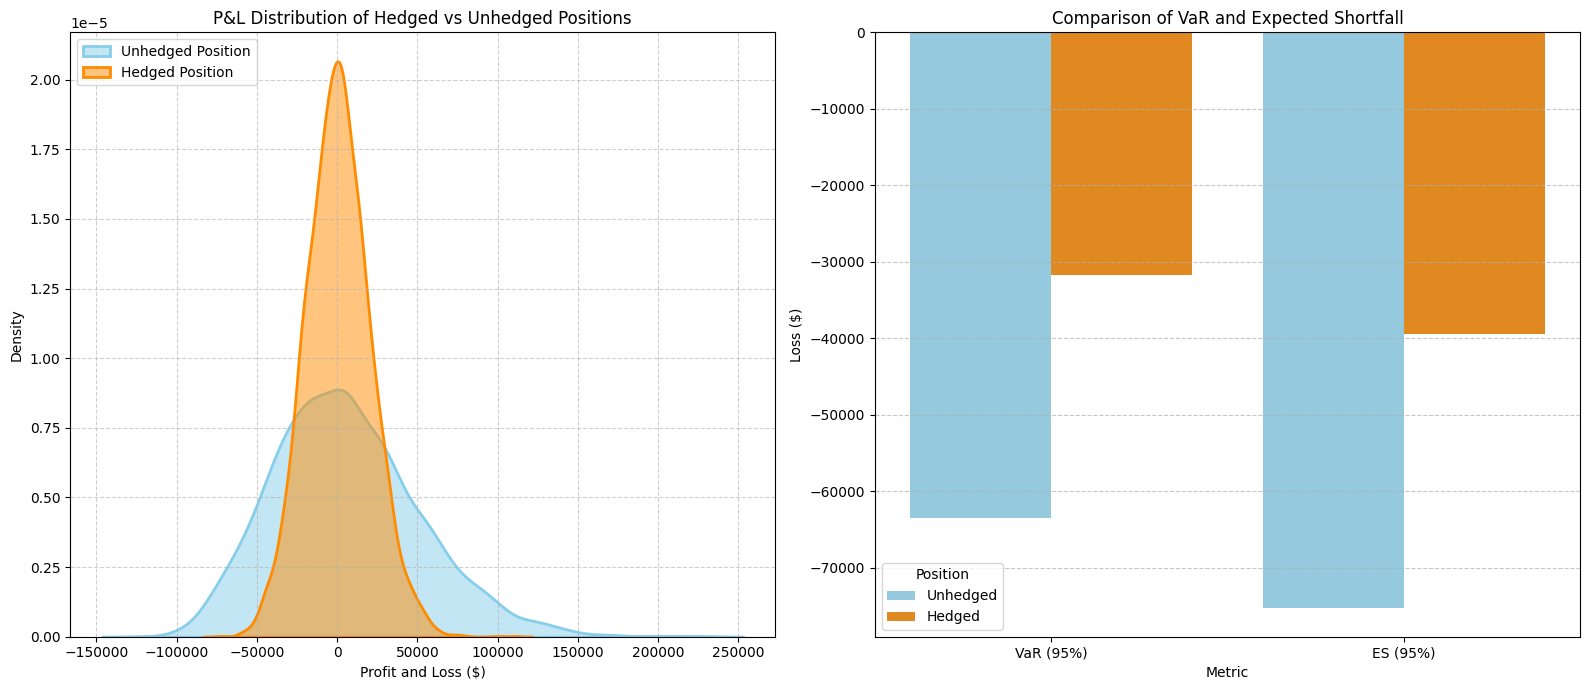

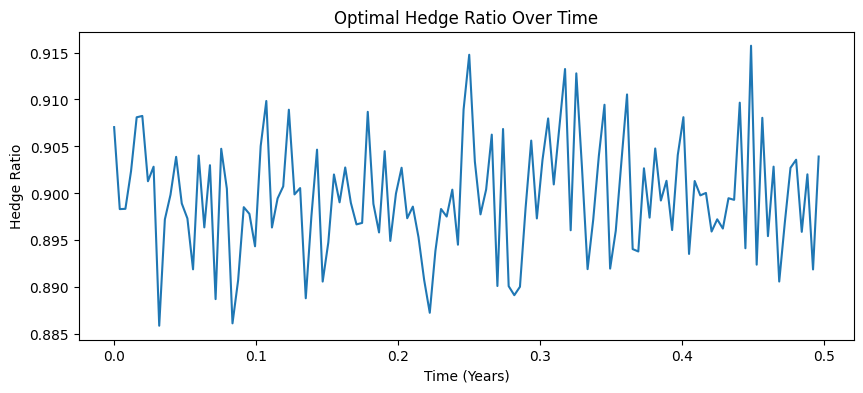

In [37]:
def calculate_risk_metrics(pnl, confidence_level=0.95):
  pnl_sorted = np.sort(pnl)
  index = int((1 - confidence_level) * len(pnl_sorted))
  VaR = -pnl_sorted[index]
  ES = -np.mean(pnl_sorted[:index])
  return VaR, ES

# Hedged position risk metrics at 95% confidence level
VaR_hedged, ES_hedged = calculate_risk_metrics(pnl_hedged)

# Unhedged position risk metrics
VaR_unhedged, ES_unhedged = calculate_risk_metrics(pnl_unhedged)

# Create a figure with two subplots
plt.figure(figsize=(16, 7))

# Subplot 1: P&L Distribution
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.kdeplot(pnl_unhedged, fill=True, label='Unhedged Position', alpha=0.5, linewidth=2, color='skyblue')
sns.kdeplot(pnl_hedged, fill=True, label='Hedged Position', alpha=0.5, linewidth=2, color='darkorange')
plt.title("P&L Distribution of Hedged vs Unhedged Positions")
plt.xlabel('Profit and Loss ($)')
plt.ylabel('Density')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Prepare data for VaR/ES comparison bar chart
risk_data = {
    'Metric': ['VaR (95%)', 'ES (95%)', 'VaR (95%)', 'ES (95%)'],
    'Position': ['Unhedged', 'Unhedged', 'Hedged', 'Hedged'],
    'Value': [-VaR_unhedged, -ES_unhedged, -VaR_hedged, -ES_hedged] # Negate to show as positive losses
}
df_risk_compare = pd.DataFrame(risk_data)

# Subplot 2: VaR and ES Comparison
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='Metric', y='Value', hue='Position', data=df_risk_compare,
            palette={'Unhedged': 'skyblue', 'Hedged': 'darkorange'})
plt.title('Comparison of VaR and Expected Shortfall')
plt.ylabel('Loss ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Position')
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


# Hedge Ratios over time (kept as a separate plot for clarity)
plt.figure(figsize=(10, 4))
plt.plot(np.arange(N_steps) * dt, hedge_ratios)
plt.title('Optimal Hedge Ratio Over Time')
plt.xlabel('Time (Years)')
plt.ylabel('Hedge Ratio')
plt.show()

### 7. Conclusions - Wrapping Up

**P&L Distribution of Hedged vs. Unhedged Positions:**

This graph clearly illustrates the core benefit and trade-off of hedging:

*   **Reduced Risk for Hedged Position:** The hedged position's distribution (orange) is much narrower and more concentrated around zero compared to the unhedged position (blue). This indicates that hedging successfully reduced the variability of potential profits and losses. The tails of the hedged distribution are significantly shorter, meaning extreme losses (and gains) are less likely.
*   **Downside Protection:** The left tail of the hedged distribution is much less severe than that of the unhedged position. This confirms that hedging provides crucial protection against significant losses.
*   **Limited Upside:** While reducing downside risk, hedging also limits potential upside gains. The right tail of the hedged distribution is also shorter, meaning that in very favorable market conditions, the unhedged position could have realized much larger profits.
*   **Central Tendency:** The hedged distribution is centered closer to zero, indicating that the hedging strategy aimed to lock in the value of the underlying asset, minimizing the impact of price fluctuations on the overall P&L.

In essence, the P&L distribution shows that hedging shifts the risk-reward profile: it sacrifices some potential for large gains to gain significant protection against large losses, resulting in a more predictable outcome.

**Optimal Hedge Ratio Over Time:**

This plot shows how the optimal hedge ratio, `h*`, changes at each time step throughout the simulation duration.

*   **Dynamic Nature of Hedging:** The hedge ratio is not constant; it fluctuates over time. This is because market conditions (like the correlation between spot and futures price changes, and their respective volatilities) are constantly evolving. A truly optimal hedging strategy needs to adapt to these changes.
*   **Responsiveness to Market Conditions:** The linear regression model used to calculate `h*` at each step allows the hedge to be dynamically adjusted based on recent price movements. If, for instance, the relationship between spot and futures prices strengthens or weakens, the optimal number of futures contracts to hold will change accordingly.
*   **Basis Risk and Imperfect Correlation:** The fact that the hedge ratio is not always exactly 1 (or -1, depending on how it's defined and the position) suggests the presence of basis risk. If spot and futures prices moved in perfect lockstep, the hedge ratio would be constant and predictable. Its fluctuations demonstrate the challenge of perfectly offsetting risk in real markets.

**Comparison of VaR and Expected Shortfall:**

The bar plot comparing VaR and ES for hedged versus unhedged positions vividly demonstrates the quantitative impact of hedging on downside risk:

*   **Significant Risk Reduction:** The VaR and ES values for the hedged position are substantially lower (less negative) than those for the unhedged position. This is a clear indicator that the dynamic hedging strategy effectively reduced the potential for extreme losses.
*   **Understanding Tail Risk:** Both VaR and ES focus on the 'tail' of the P&L distribution, representing the worst-case outcomes. The reduction in these metrics for the hedged position means that not only are large losses less frequent, but also the *magnitude* of those large losses, when they do occur, is significantly mitigated.
*   **Quantitative Evidence:** This comparison provides strong quantitative evidence supporting the qualitative observations from the P&L distribution: hedging moves the risk profile towards more contained and manageable losses.

Combined, these graphs demonstrate the efficacy and dynamic requirements of a hedging strategy, highlighting how it manages risk and adapts to changing market conditions.